
# Ensemble Model for Coral Image Classification

This notebook integrates a custom CNN with CBAM and a VGG19-based model using a voting mechanism.


In [1]:

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Average
from tensorflow.keras.applications import VGG19
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Add, Multiply, Conv2D, Input
from tensorflow.keras.optimizers import Adam
import numpy as np


In [2]:

# Paths to dataset directories
train_dir = r"C:\Users\THANUJ RAJA\OneDrive\Desktop\dl\Bleached Corals and Healthy Corals Classification\Training"
validation_dir = r"C:\Users\THANUJ RAJA\OneDrive\Desktop\dl\Bleached Corals and Healthy Corals Classification\Validation"
test_dir = r"C:\Users\THANUJ RAJA\OneDrive\Desktop\dl\Bleached Corals and Healthy Corals Classification\Testing"
# Image data generator
data_gen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = data_gen.flow_from_directory(
    train_dir, 
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)
validation_generator = data_gen.flow_from_directory(
    validation_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)
test_generator = data_gen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary', shuffle=False
)


Found 7384 images belonging to 2 classes.
Found 985 images belonging to 2 classes.
Found 923 images belonging to 2 classes.


In [3]:

def build_cnn_with_cbam(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = cbam_block(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = cbam_block(x)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def cbam_block(input_tensor, reduction_ratio=8):
    channel = input_tensor.shape[-1]
    avg_pool = GlobalAveragePooling2D()(input_tensor)
    max_pool = GlobalMaxPooling2D()(input_tensor)
    shared_dense = Dense(channel // reduction_ratio, activation='relu', use_bias=False)
    avg_out = shared_dense(avg_pool)
    max_out = shared_dense(max_pool)
    channel_attention = Add()([avg_out, max_out])
    channel_attention = Dense(channel, activation='sigmoid')(channel_attention)
    channel_attention = Multiply()([input_tensor, channel_attention])

    spatial_attention = Conv2D(1, kernel_size=7, activation='sigmoid', padding='same')(
        Add()([
            tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_attention),
            tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_attention)
        ])
    )
    return Multiply()([channel_attention, spatial_attention])


In [4]:

def build_vgg19(input_shape):
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base_model.layers:
        layer.trainable = False

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [5]:

cnn_model = build_cnn_with_cbam((128, 128, 3))
vgg19_model = build_vgg19((128, 128, 3))

# Train individual models (example, adjust epochs as needed)
cnn_model.fit(train_generator, validation_data=validation_generator, epochs=20)
vgg19_model.fit(train_generator, validation_data=validation_generator, epochs=10)

# Get predictions from both models
cnn_predictions = cnn_model.predict(test_generator)
vgg19_predictions = vgg19_model.predict(test_generator)

# Ensemble voting mechanism (average probability for binary classification)
ensemble_predictions = (cnn_predictions + vgg19_predictions) / 2
final_predictions = (ensemble_predictions > 0.5).astype(int)

# Evaluate ensemble accuracy
true_labels = test_generator.classes

accuracy = np.mean(final_predictions.flatten() == true_labels)
print(f"Ensemble Accuracy: {accuracy * 100:.2f}%")



Epoch 1/20


c:\Users\THANUJ RAJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


231/231 ━━━━━━━━━━━━━━━━━━━━ 30s 120ms/step - accuracy: 0.6417 - loss: 0.6277 - val_accuracy: 0.7137 - val_loss: 0.5565
Epoch 2/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 38s 163ms/step - accuracy: 0.7340 - loss: 0.5212 - val_accuracy: 0.7452 - val_loss: 0.5138
Epoch 3/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.7606 - loss: 0.4955 - val_accuracy: 0.7452 - val_loss: 0.5092
Epoch 4/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 26s 114ms/step - accuracy: 0.7768 - loss: 0.4626 - val_accuracy: 0.7482 - val_loss: 0.5001
Epoch 5/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.8023 - loss: 0.4289 - val_accuracy: 0.7807 - val_loss: 0.4673
Epoch 6/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - accuracy: 0.8319 - loss: 0.3678 - val_accuracy: 0.7492 - val_loss: 0.5130
Epoch 7/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - accuracy: 0.8616 - loss: 0.3106 - val_accuracy: 0.7604 - val_loss: 0.5501
Epoch 8/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 27s 117ms/step - accuracy: 0.9150 - loss: 0.2090 - val

In [13]:
# Assuming `test_generator` is properly defined to yield test data
cnn_loss, cnn_accuracy = cnn_model.evaluate(test_generator, steps=len(test_generator))

# Print the metrics
print(f"CNN Test Loss: {cnn_loss}")
print(f"CNN Test Accuracy: {cnn_accuracy}")

vgg19_loss, vgg19_accuracy = vgg19_model.evaluate(test_generator, steps=len(test_generator))

# Print the metrics
print(f"VGG Test Loss: {vgg19_loss}")
print(f"VGG Test Accuracy: {vgg19_accuracy}")


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7056 - loss: 1.6374
CNN Test Loss: 1.2189966440200806
CNN Test Accuracy: 0.7703142166137695
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 533ms/step - accuracy: 0.8898 - loss: 0.2942
VGG Test Loss: 0.4402499198913574
VGG Test Accuracy: 0.8288190960884094


In [15]:
from sklearn.metrics import classification_report
import numpy as np

# Generate predictions and classification report for CNN model
cnn_predictions = (cnn_model.predict(test_generator, steps=len(test_generator)) > 0.5).astype("int32").flatten()
cnn_true_labels = test_generator.classes  # True labels from the generator

cnn_report = classification_report(cnn_true_labels, cnn_predictions, target_names=test_generator.class_indices.keys())
print("CNN Model Classification Report:")
print(cnn_report)

# Generate predictions and classification report for VGG19 model
vgg19_predictions = (vgg19_model.predict(test_generator, steps=len(test_generator)) > 0.5).astype("int32").flatten()
vgg19_true_labels = test_generator.classes  # True labels from the generator

vgg19_report = classification_report(vgg19_true_labels, vgg19_predictions, target_names=test_generator.class_indices.keys())
print("VGG19 Model Classification Report:")
print(vgg19_report)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
CNN Model Classification Report:
                 precision    recall  f1-score   support

bleached_corals       0.85      0.68      0.76       485
 healthy_corals       0.71      0.87      0.78       438

       accuracy                           0.77       923
      macro avg       0.78      0.78      0.77       923
   weighted avg       0.79      0.77      0.77       923

29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 531ms/step
VGG19 Model Classification Report:
                 precision    recall  f1-score   support

bleached_corals       0.79      0.93      0.85       485
 healthy_corals       0.90      0.72      0.80       438

       accuracy                           0.83       923
      macro avg       0.84      0.82      0.83       923
   weighted avg       0.84      0.83      0.83       923



29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 535ms/step


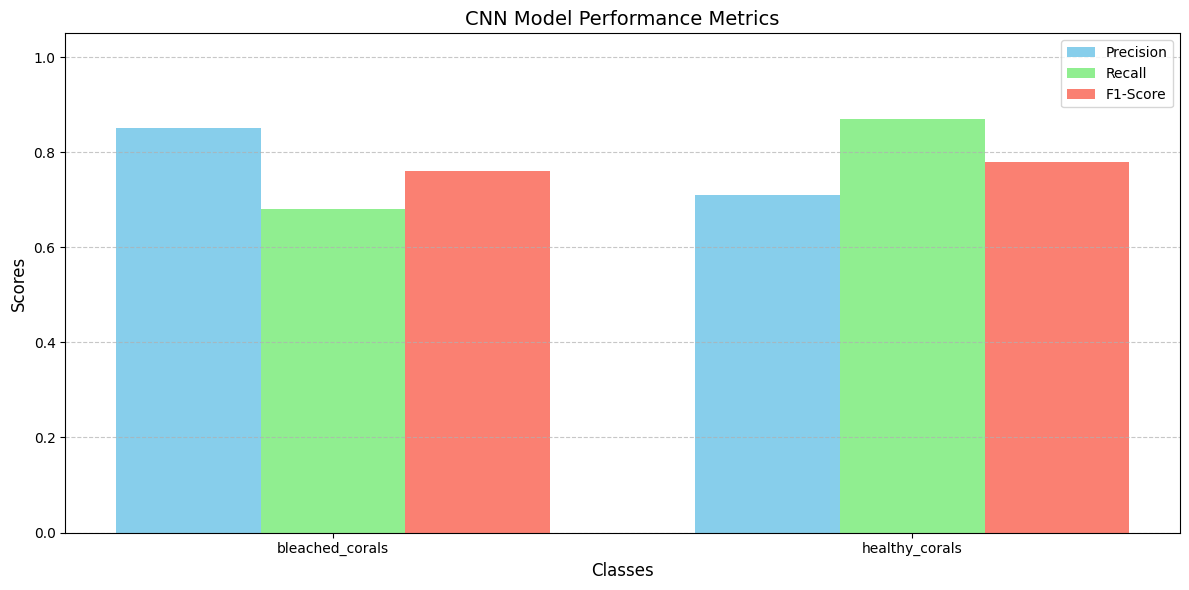

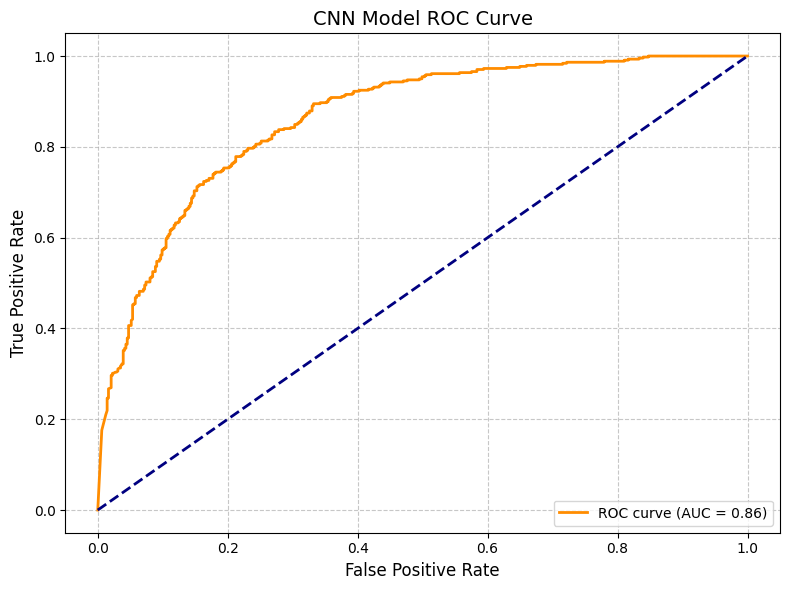

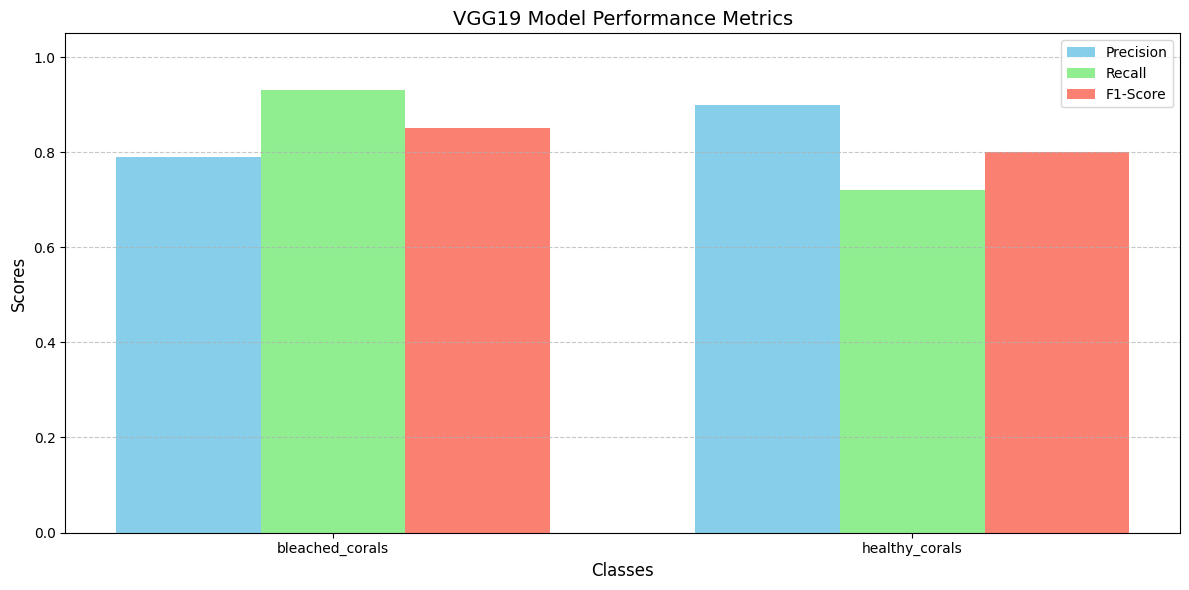

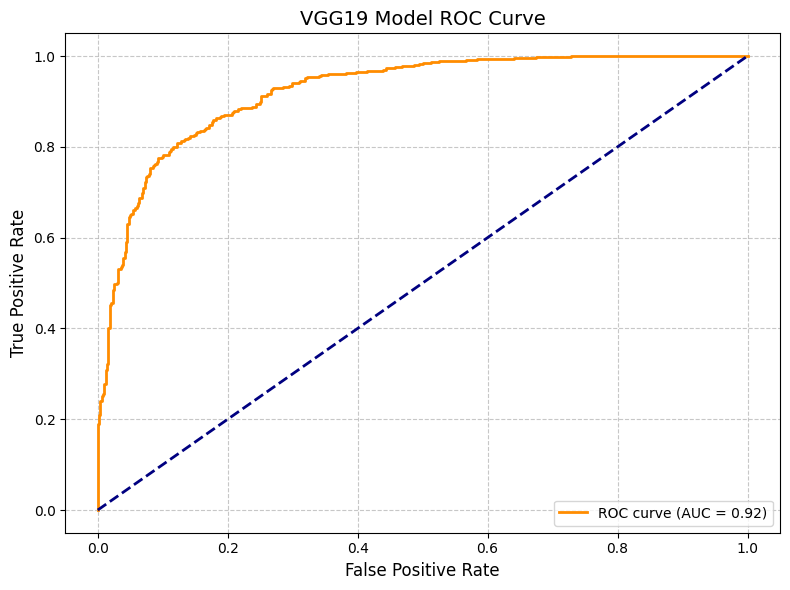

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, roc_curve, auc

# Function to parse the classification report into a dictionary
def parse_classification_report(report):
    lines = report.split('\n')
    class_names = []
    metrics = {'precision': [], 'recall': [], 'f1-score': [], 'support': []}
    
    for line in lines[2:]:  # Skip header lines
        if line.strip() == "" or "accuracy" in line or "avg" in line:
            continue  # Skip lines with averages or overall accuracy
        parts = line.split()
        class_names.append(parts[0])
        metrics['precision'].append(float(parts[1]))
        metrics['recall'].append(float(parts[2]))
        metrics['f1-score'].append(float(parts[3]))
        metrics['support'].append(int(parts[4]))
    return class_names, metrics

# Function to plot metrics
def plot_metrics(class_names, metrics, model_name):
    x = np.arange(len(class_names))
    width = 0.25

    # Plot Precision, Recall, F1-Score
    plt.figure(figsize=(12, 6))
    plt.bar(x - width, metrics['precision'], width, label='Precision', color='skyblue')
    plt.bar(x, metrics['recall'], width, label='Recall', color='lightgreen')
    plt.bar(x + width, metrics['f1-score'], width, label='F1-Score', color='salmon')

    plt.xlabel('Classes', fontsize=12)
    plt.ylabel('Scores', fontsize=12)
    plt.title(f'{model_name} Performance Metrics', fontsize=14)
    plt.xticks(x, class_names, fontsize=10)
    plt.ylim(0, 1.05)
    plt.legend(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Function to plot ROC Curve
def plot_roc_curve(true_labels, predicted_probs, model_name):
    fpr, tpr, _ = roc_curve(true_labels, predicted_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{model_name} ROC Curve', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Generate predictions and true labels
cnn_predictions = cnn_model.predict(test_generator, steps=len(test_generator)).flatten()
cnn_true_labels = test_generator.classes
vgg19_predictions = vgg19_model.predict(test_generator, steps=len(test_generator)).flatten()
vgg19_true_labels = test_generator.classes

# Parse classification reports
cnn_class_names, cnn_metrics = parse_classification_report(cnn_report)
vgg19_class_names, vgg19_metrics = parse_classification_report(vgg19_report)

# Plot metrics for CNN Model
plot_metrics(cnn_class_names, cnn_metrics, "CNN Model")
plot_roc_curve(cnn_true_labels, cnn_predictions, "CNN Model")

# Plot metrics for VGG19 Model
plot_metrics(vgg19_class_names, vgg19_metrics, "VGG19 Model")
plot_roc_curve(vgg19_true_labels, vgg19_predictions, "VGG19 Model")


In [ ]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Confusion matrix and classification report
def evaluate_ensemble(true_labels, predictions):
    # Confusion matrix
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Bleached'], yticklabels=['Healthy', 'Bleached'])
    plt.title("Confusion Matrix for Ensemble Model")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Classification report
    report = classification_report(true_labels, predictions, target_names=['Healthy', 'Bleached'])
    print("Classification Report:\n", report)

evaluate_ensemble(test_generator.classes, final_predictions.flatten())


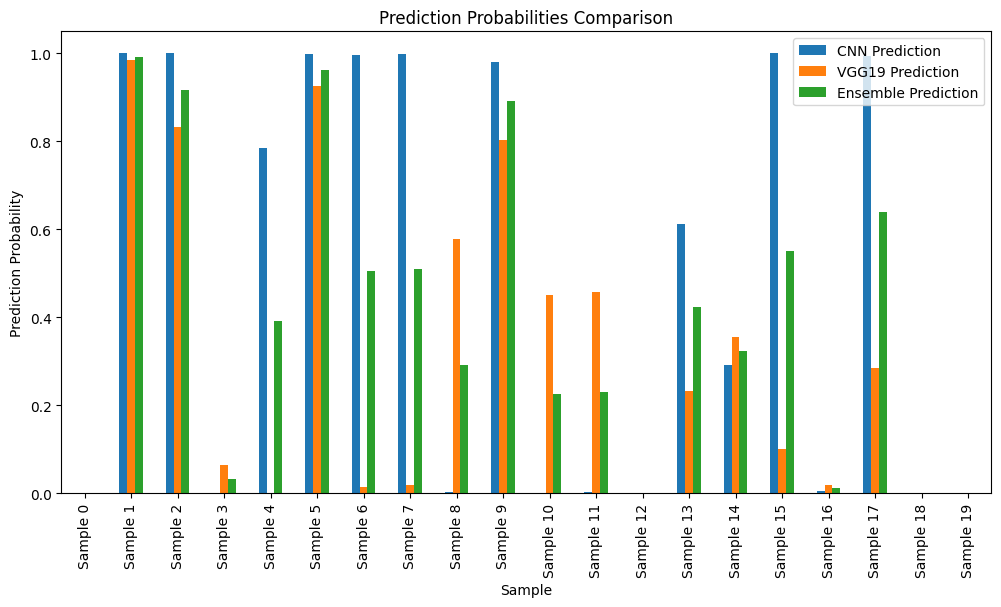

In [20]:

import pandas as pd

# Plot predictions comparison
def plot_predictions_comparison(cnn_preds, vgg_preds, ensemble_preds, sample_indices):
    sample_cnn = cnn_preds[sample_indices]
    sample_vgg = vgg_preds[sample_indices]
    sample_ensemble = ensemble_preds[sample_indices]

    df = pd.DataFrame({
        "Sample": [f"Sample {i}" for i in sample_indices],
        "CNN Prediction": sample_cnn.flatten(),
        "VGG19 Prediction": sample_vgg.flatten(),
        "Ensemble Prediction": sample_ensemble.flatten()
    })
    df.plot(x="Sample", kind="bar", figsize=(12, 6))
    plt.title("Prediction Probabilities Comparison")
    plt.ylabel("Prediction Probability")
    plt.show()

# Plot for first 20 samples
sample_indices = list(range(20))
plot_predictions_comparison(cnn_predictions, vgg19_predictions, ensemble_predictions, sample_indices)


Ensemble Model Classification Report:
                 precision    recall  f1-score   support

bleached_corals       0.87      0.81      0.84       485
 healthy_corals       0.80      0.87      0.83       438

       accuracy                           0.84       923
      macro avg       0.84      0.84      0.84       923
   weighted avg       0.84      0.84      0.84       923



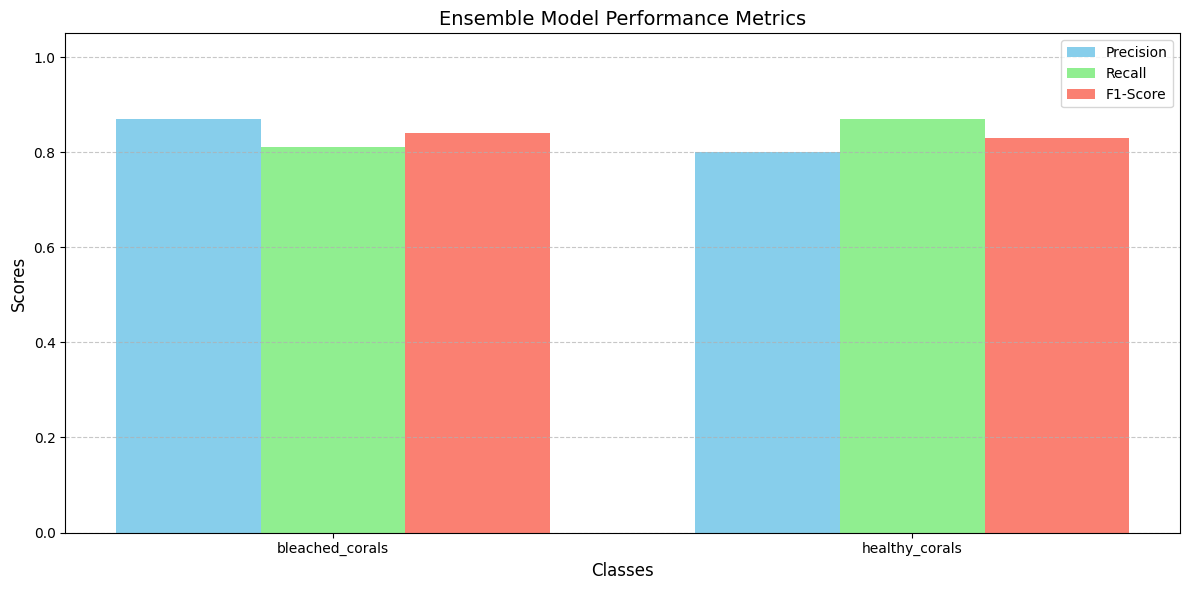

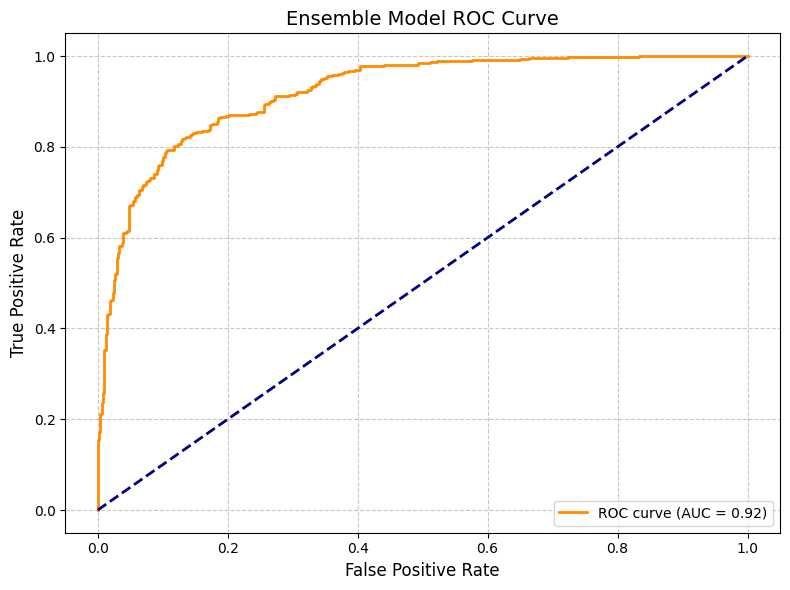

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, auc
import numpy as np

# Generate a classification report
ensemble_report = classification_report(true_labels, final_predictions, target_names=test_generator.class_indices.keys())
print("Ensemble Model Classification Report:")
print(ensemble_report)

# Function to parse the classification report into a dictionary
def parse_classification_report(report):
    lines = report.split('\n')
    class_names = []
    metrics = {'precision': [], 'recall': [], 'f1-score': [], 'support': []}
    
    for line in lines[2:]:  # Skip header lines
        if line.strip() == "" or "accuracy" in line or "avg" in line:
            continue  # Skip lines with averages or overall accuracy
        parts = line.split()
        class_names.append(parts[0])
        metrics['precision'].append(float(parts[1]))
        metrics['recall'].append(float(parts[2]))
        metrics['f1-score'].append(float(parts[3]))
        metrics['support'].append(int(parts[4]))
    return class_names, metrics

# Function to plot metrics
def plot_metrics(class_names, metrics, model_name):
    x = np.arange(len(class_names))
    width = 0.25

    # Plot Precision, Recall, F1-Score
    plt.figure(figsize=(12, 6))
    plt.bar(x - width, metrics['precision'], width, label='Precision', color='skyblue')
    plt.bar(x, metrics['recall'], width, label='Recall', color='lightgreen')
    plt.bar(x + width, metrics['f1-score'], width, label='F1-Score', color='salmon')

    plt.xlabel('Classes', fontsize=12)
    plt.ylabel('Scores', fontsize=12)
    plt.title(f'{model_name} Performance Metrics', fontsize=14)
    plt.xticks(x, class_names, fontsize=10)
    plt.ylim(0, 1.05)
    plt.legend(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Function to plot ROC Curve
def plot_roc_curve(true_labels, predicted_probs, model_name):
    fpr, tpr, _ = roc_curve(true_labels, predicted_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{model_name} ROC Curve', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Parse classification report for ensemble model
ensemble_class_names, ensemble_metrics = parse_classification_report(ensemble_report)

# Plot metrics for Ensemble Model
plot_metrics(ensemble_class_names, ensemble_metrics, "Ensemble Model")

# Plot ROC Curve for Ensemble Model
ensemble_probs = ensemble_predictions.flatten()  # Use probabilities for ROC
plot_roc_curve(true_labels, ensemble_probs, "Ensemble Model")
